## WormLib 
## Example 1 - single cell segmentation with spot detection and spatial analysis

In [56]:
# Check the Python environment
import sys, os
print("Python executable:", sys.executable)
print("Prefix:", sys.prefix)
print("Conda env:", os.environ.get("CONDA_DEFAULT_ENV"))
print("VIRTUAL_ENV:", os.environ.get("VIRTUAL_ENV"))


# WormLib isn't published to PyPi yet, manually resolve src/directory and import WormLib functions
current_dir = PathlibPath().resolve()
script_dir = PathlibPath(".").resolve()
search_roots = [current_dir, *current_dir.parents, script_dir, *script_dir.parents]
src_dir = next((root / 'src' for root in search_roots if (root / 'src').is_dir()), None)

if src_dir is None:
    raise RuntimeError("Could not find the WormLib src directory.")

sys.path.insert(0, str(src_dir))
main_dir = PathlibPath(src_dir.parent)

print(f"Source directory: {src_dir}")
print(f"Main directory: {main_dir}")
print(f"Current working directory: {current_dir}")

Python executable: /opt/anaconda3/envs/wormlib/bin/python
Prefix: /opt/anaconda3/envs/wormlib
Conda env: wormlib
VIRTUAL_ENV: None
Source directory: /Users/nalytorres/Documents/GitHub/WormLib/src
Main directory: /Users/nalytorres/Documents/GitHub/WormLib
Current working directory: /Users/nalytorres/Documents/GitHub/WormLib/examples


In [57]:
# Import core packages
import bigfish
import bigfish.stack as stack
import bigfish.plot as plot
import csv
from datetime import datetime
from IPython.display import display, Image
import joblib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
from matplotlib.path import Path
from mpl_toolkits.mplot3d import Axes3D
import nd2
import numpy as np
import pandas as pd
from PIL import Image as PILImage
import plotly.graph_objects as go
from reportlab.lib import colors
from reportlab.lib.pagesizes import letter
from reportlab.pdfgen import canvas
from reportlab.lib.units import inch
from reportlab.platypus import Table, TableStyle, SimpleDocTemplate
from scipy.ndimage import binary_dilation, label, gaussian_filter, rotate, center_of_mass, zoom
from scipy.spatial import cKDTree
import seaborn as sns
import skimage
from skimage import measure, morphology, filters
from skimage.draw import polygon2mask
from skimage.feature import canny
from skimage.measure import label, regionprops, regionprops_table
from skimage.morphology import square, dilation, erosion, disk, binary_erosion
from skimage.transform import resize
from skimage.util import img_as_float
from sklearn.ensemble import RandomForestClassifier
from sklearn.exceptions import InconsistentVersionWarning
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tifffile
import tifffile as tiff
import time
import warnings
import wormlib
from pathlib import Path as PathlibPath


warnings.filterwarnings(
    "ignore",
    message="Problem occurs during the decomposition of dense regions.*",
    category=UserWarning
)

print("\nWelcome to WormLib Example Notebook!")


Welcome to WormLib Example Notebook!


## 1. Input Configuration

In [60]:
# ============================================================================
# 1.1 Input Configuration
# ============================================================================

# Image path
folder_name = main_dir / "data/230713_Lp306_L4440_11"

# Microscope parameters
voxel_size = (1448, 450, 450)  # Z, Y, X in nm
spot_radius_ch0 = (1409, 340, 340)  # PSF for channel 0 (Cy5)
spot_radius_ch1 = (1283, 310, 310)  # PSF for channel 1 (mCherry)

# Channel names (set to None if the channel does not exist)
ch0 = "set3_mRNA"  # (Q670)
ch1 = "erm1_mRNA"  # (Q610)
ch2 = "ERM1_protein"  # (GFP)
ch3 = "DAPI"
brightfield = "brightfield"

# Image type selection
dv_images = True
nd2_images = False
tiff_images = False

# Pipeline flags
run_embryo_segmentation = False
run_cell_segmentation = True
run_cell_classifier = True
run_spot_detection = True
run_mRNA_heatmaps = True
run_rna_density_analysis = True
run_line_scan_analysis = True
calculate_gfp_mask_colocalization = True
calculate_nuclei_colocalization = True
generate_donut_mask = True
calculate_membrane_colocalization = True
run_concentric_layers_analysis = True
generate_pgranule_mask = True
calculate_pgranule_colocalization = True
calculate_mRNA_mRNA_colocalization = True
run_protein_heatmaps = True

# Segmentation parameters
embryo_diameter = 375
nuclei_diameter = 30
cell_diameter = 250

# Output directory
output_directory = os.path.join(
    os.path.dirname(str(folder_name)), 
    "output", 
    os.path.basename(str(folder_name))
)
os.makedirs(output_directory, exist_ok=True)

print(f"Image folder: {folder_name}")
print(f"Output directory: {output_directory}")
print(f"Pipeline configuration loaded.")

Image folder: /Users/nalytorres/Documents/GitHub/WormLib/data/230713_Lp306_L4440_11
Output directory: /Users/nalytorres/Documents/GitHub/WormLib/data/output/230713_Lp306_L4440_11
Pipeline configuration loaded.


## 2. Load Images

In [45]:
# Load brightfield/reference image
image_ref = folder_name / "230713_Lp306_L4440_11_R3D_REF.dv"
image_path = folder_name / "230713_Lp306_L4440_11_R3D.dv"

print(f"Reference image: {image_ref}")
print(f"Color image: {image_path}")
print(f"Files exist: ref={image_ref.exists()}, color={image_path.exists()}")

Reference image: /Users/nalytorres/Documents/GitHub/WormLib/data/230713_Lp306_L4440_11/230713_Lp306_L4440_11_R3D_REF.dv
Color image: /Users/nalytorres/Documents/GitHub/WormLib/data/230713_Lp306_L4440_11/230713_Lp306_L4440_11_R3D.dv
Files exist: ref=True, color=True


Detected DeltaVision (.dv) images
Image ID: 230713_Lp306_L4440_11

Processing file 230713_Lp306_L4440_11_R3D_REF.dv with shape: (1024, 1024)
Loaded 2D brightfield image


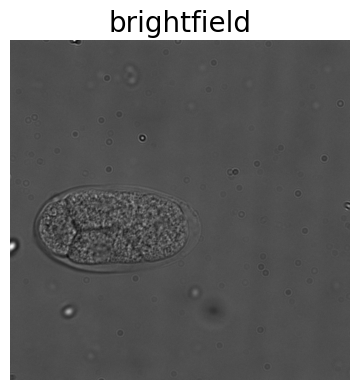

Brightfield image loaded.
Detected DeltaVision (.dv) images
Image ID: 230713_Lp306_L4440_11

Processing file 230713_Lp306_L4440_11_R3D.dv with shape: (4, 51, 1024, 1024)
Loaded 4D color channel stack


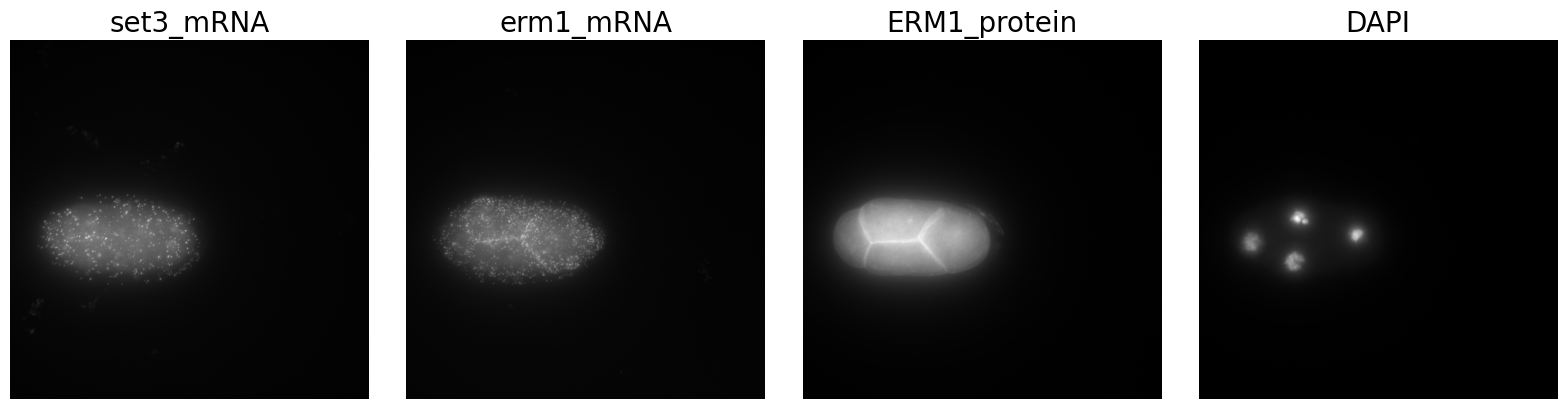

Color image loaded.


In [46]:
# Load images using WormLib function
bf_result = None
if image_ref.exists():
    bf_result = wormlib.load_images(
        image_path=str(image_ref),
        output_directory=output_directory,
        channel_names={'brightfield': brightfield},
        slice_to_plot=12,
    )
    print("Brightfield image loaded.")

color_result = None
if image_path.exists():
    channel_names = {
        'Cy5': ch0,
        'mCherry': ch1,
        'FITC': ch2,
        'DAPI': ch3,
        'brightfield': None,
    }
    channel_indices = {
        'Cy5': 0,
        'mCherry': 1,
        'FITC': 2,
        'DAPI': 3,
        'brightfield': None,
    }
    color_result = wormlib.load_images(
        image_path=str(image_path),
        output_directory=output_directory,
        channel_names=channel_names,
        channel_indices=channel_indices,
        slice_to_plot=12,
    )
    print("Color image loaded.")

In [47]:
# Unpack results
bf = bf_result['bf'] if bf_result else None
image_name = bf_result['image_name'] if bf_result else (color_result['image_name'] if color_result else "unknown")

image_ch0 = color_result.get('image_Cy5') if color_result else None
image_ch1 = color_result.get('image_mCherry') if color_result else None
image_ch2 = color_result.get('image_nuclei') if color_result else None  # Placeholder
image_ch3 = color_result.get('image_nuclei') if color_result else None  # Placeholder

ch0_array = color_result.get('Cy5_array') if color_result else None
ch1_array = color_result.get('mCherry_array') if color_result else None

grid_width = color_result.get('grid_width', 80) if color_result else 80
grid_height = color_result.get('grid_height', 80) if color_result else 80

print(f"Image name: {image_name}")
print(f"Brightfield shape: {bf.shape if bf is not None else 'None'}")
print(f"Channel 0 array shape: {ch0_array.shape if ch0_array is not None else 'None'}")
print(f"Channel 1 array shape: {ch1_array.shape if ch1_array is not None else 'None'}")

Image name: 230713_Lp306_L4440_11
Brightfield shape: (1024, 1024)
Channel 0 array shape: (51, 1024, 1024)
Channel 1 array shape: (51, 1024, 1024)


## 3. Segmentation

Running cell segmentation...


/opt/anaconda3/envs/wormlib/lib/python3.11/site-packages/cellpose/resnet_torch.py:275: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(filename, map_lo

Detected 4 nuclei after filtering → Stage: 4-cell
run_2cell_classifier = False
run_4cell_classifier = True
run_embryo_segmentation = False
Cell stage: 4-cell


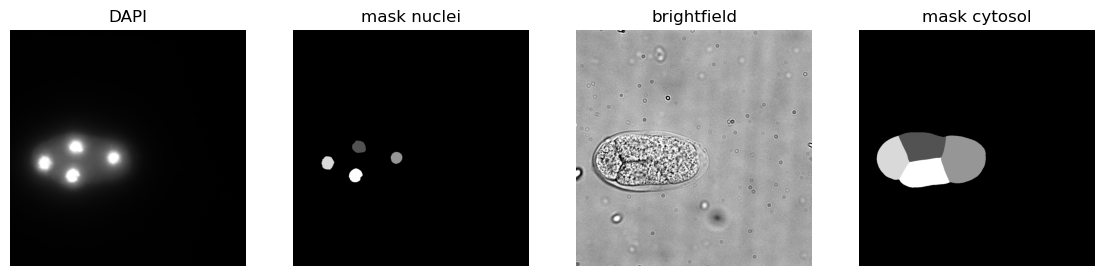

In [48]:
# Cell segmentation
masks_cytosol = None
masks_nuclei = None
features_df = None
cell_stage = "no-nuclei"
fallback_to_embryo = False

if run_cell_segmentation and bf is not None and image_ch2 is not None:
    print("Running cell segmentation...")
    image_cytosol = bf
    second_image_cytosol = image_ch2  # DAPI channel
    
    masks_cytosol, masks_nuclei, _, _ = wormlib.segmentation(
        image_cytosol, 
        image_ch2,  # nuclei image
        second_image_cytosol,
        output_directory=output_directory,
    )
    
    # Determine cell stage
    cell_stage, nuclei_sizes, masks_filtered = wormlib.get_cell_stage_and_size_filtered(
        masks_nuclei, voxel_size
    )
    print(f"Cell stage: {cell_stage}")
elif run_cell_segmentation and bf is None and image_ch2 is not None:
    print("Running nuclear-only segmentation...")
    masks_nuclei = wormlib.nuclear_segmentation(image_ch2)
    masks_cytosol = masks_nuclei
    cell_stage = "nuclei-only"
    run_cell_classifier = False

Running 4-cell classifier...
Model classes: ['ABa', 'ABb', 'EMS', 'P2']
[classify_4cell] Using alias 'ABb' for expected class 'ABp'.


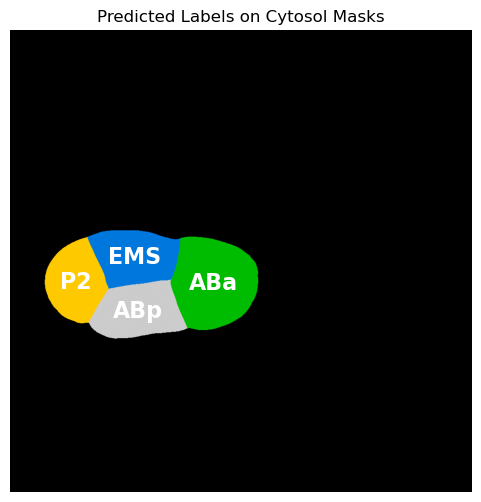

   label     area   perimeter  eccentricity  solidity    extent  \
0      1  19956.0  600.362482      0.768798  0.967048  0.747332   
1      2  31203.0  688.014285      0.386323  0.983825  0.773021   
2      3  18288.0  537.813275      0.682986  0.984708  0.674287   
3      4  20427.0  606.995995      0.798306  0.962856  0.703409   

   major_axis_length  minor_axis_length  mean_intensity  bbox-0  ...  \
0         203.240212         129.970490      535.724895     444  ...   
1         209.274280         193.026980      529.861231     458  ...   
2         179.598543         131.184436      514.670057     459  ...   
3         211.841607         127.582064      508.396877     552  ...   

   medianf_std  medianf_median  initial_prediction  prediction_confidence  \
0    20.059712           213.0                 ABb                   0.46   
1    19.237042           211.0                 ABa                   0.64   
2    23.870346           204.0                  P2                   0.6

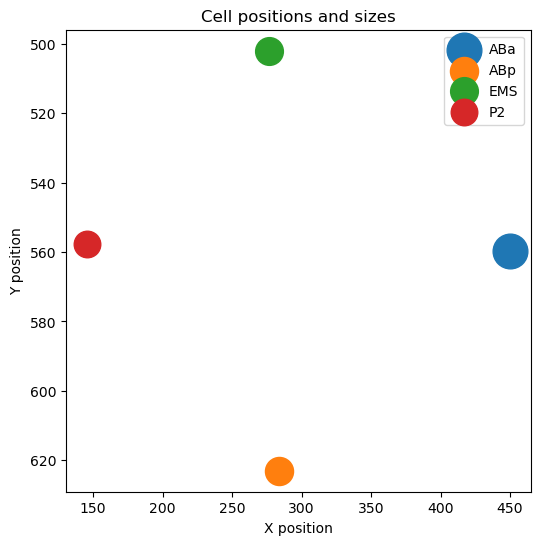

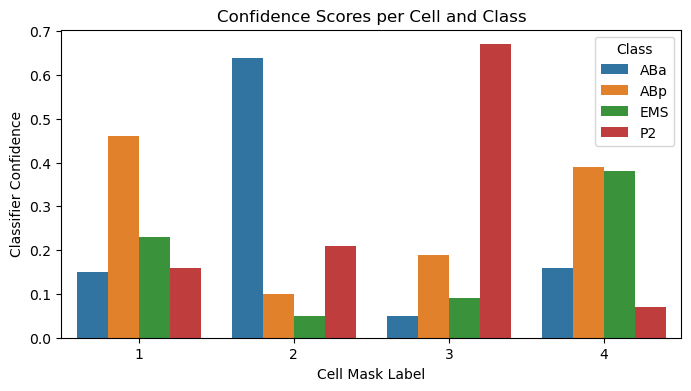

In [49]:
# Cell classification
if run_cell_classifier and masks_cytosol is not None:
    models_dir = main_dir / "models"
    model_2cell_path = models_dir / "2-cell_classification_RFmodel.joblib"
    model_4cell_path = models_dir / "4-cell_classification_RFmodel.joblib"
    
    if cell_stage == "2-cell" and model_2cell_path.exists():
        print("Running 2-cell classifier...")
        features_df = wormlib.classify_2cell(
            masks_cytosol=masks_cytosol, 
            bf=bf,
            image_name=image_name, 
            output_directory=output_directory,
            model_path=str(model_2cell_path), 
            verbose=True,
        )
    elif cell_stage == "4-cell" and model_4cell_path.exists():
        print("Running 4-cell classifier...")
        features_df = wormlib.classify_4cell(
            masks_cytosol=masks_cytosol, 
            bf=bf,
            image_name=image_name, 
            output_directory=output_directory,
            model_path=str(model_4cell_path), 
            verbose=True,
        )
    else:
        print(f"Classifier not available for stage '{cell_stage}'")
        run_cell_classifier = False

## 4. Spot Detection

Detecting spots in set3_mRNA...
Image ID: 230713_Lp306_L4440_11 

set3_mRNA detection
 threshold: 80.0
 spots: 1057
 clusters: 0


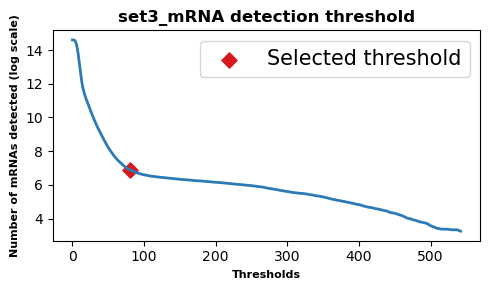

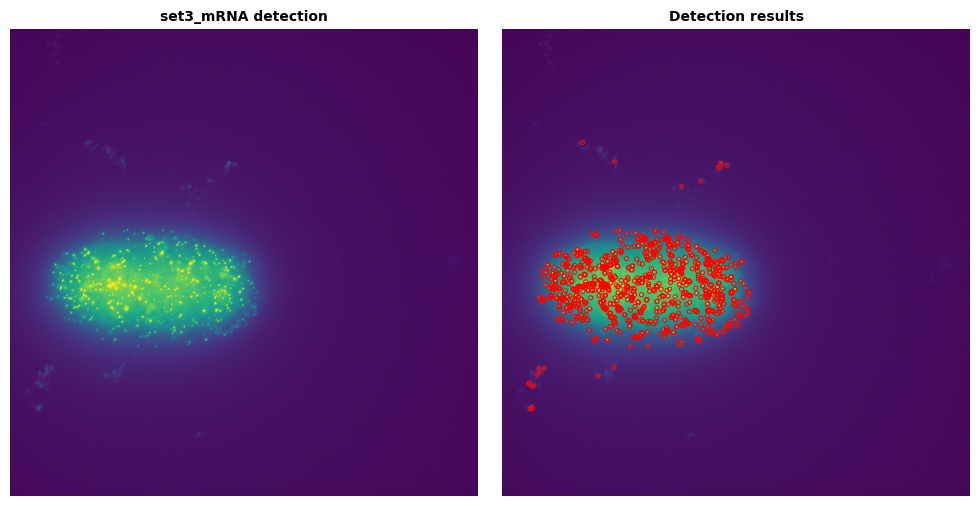

Found 4 cells with spots in set3_mRNA
Detecting spots in erm1_mRNA...
Image ID: 230713_Lp306_L4440_11 

erm1_mRNA detection
 threshold: 85.0
 spots: 2948
 clusters: 0


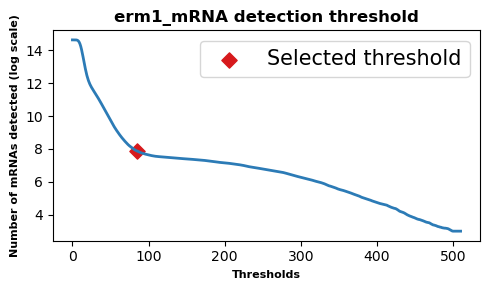

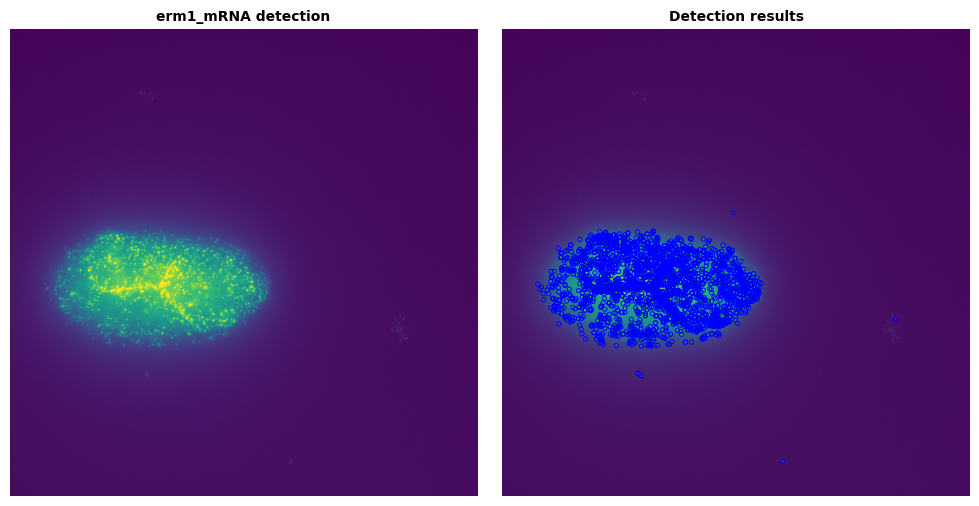

Found 4 cells with spots in erm1_mRNA


In [35]:
# Spot detection
list_spots_ch0, list_spots_ch1 = [], []
spots_post_clustering_ch0, spots_post_clustering_ch1 = None, None

if run_spot_detection and masks_cytosol is not None:
    if ch0 is not None and ch0_array is not None:
        print(f"Detecting spots in {ch0}...")
        spots_post_clustering_ch0, clusters_ch0, list_spots_ch0, _ = wormlib.spot_detection(
            ch0_array, 
            voxel_size, 
            spot_radius_ch0, 
            masks_cytosol,
            image_name=image_name, 
            rna_channel=ch0,
            detection_color="red", 
            output_directory=str(output_directory),
        )
        print(f"Found {len(list_spots_ch0)} cells with spots in {ch0}")
    
    if ch1 is not None and ch1_array is not None:
        print(f"Detecting spots in {ch1}...")
        spots_post_clustering_ch1, clusters_ch1, list_spots_ch1, _ = wormlib.spot_detection(
            ch1_array, 
            voxel_size, 
            spot_radius_ch1, 
            masks_cytosol,
            image_name=image_name, 
            rna_channel=ch1,
            detection_color="blue", 
            output_directory=str(output_directory),
        )
        print(f"Found {len(list_spots_ch1)} cells with spots in {ch1}")

## 5. Save mRNA Counts

In [36]:
# Save quantification results
sum_spots_ch0 = sum(list_spots_ch0) if list_spots_ch0 else None
sum_spots_ch1 = sum(list_spots_ch1) if list_spots_ch1 else None

if any(x is not None for x in [sum_spots_ch0, sum_spots_ch1]):
    # Wide format (total counts)
    data_wide = {'Image ID': image_name}
    if ch0 is not None and sum_spots_ch0 is not None:
        data_wide[f'{ch0} total molecules'] = sum_spots_ch0
    if ch1 is not None and sum_spots_ch1 is not None:
        data_wide[f'{ch1} total molecules'] = sum_spots_ch1
    
    df_quantification = pd.DataFrame([data_wide])
    quantification_output = os.path.join(output_directory, f'total_mRNA_counts_{image_name}.csv')
    df_quantification.to_csv(quantification_output, index=False)
    print("\nTotal mRNA counts:")
    print(df_quantification)
    
    # Long format (per-cell counts)
    num_regions = max(len(list_spots_ch0), len(list_spots_ch1)) if (list_spots_ch0 or list_spots_ch1) else 0
    if num_regions > 0:
        rows_long = []
        for i in range(num_regions):
            row = {'Image ID': image_name, 'region_id': i + 1}
            if ch0 is not None and list_spots_ch0:
                row[ch0] = list_spots_ch0[i] if i < len(list_spots_ch0) else 0
            if ch1 is not None and list_spots_ch1:
                row[ch1] = list_spots_ch1[i] if i < len(list_spots_ch1) else 0
            if features_df is not None:
                row['label'] = features_df.at[i, "highest_confidence_label"]
                row['confidence'] = round(features_df.at[i, "prediction_confidence"], 3)
            rows_long.append(row)
        
        df_long = pd.DataFrame(rows_long)
        output_prefix = "per_cell" if features_df is not None else "per_region"
        long_output = os.path.join(output_directory, f'{output_prefix}_mRNA_counts_{image_name}.csv')
        df_long.to_csv(long_output, index=False)
        print(f"\nPer-cell mRNA counts:")
        print(df_long)


Total mRNA counts:
                Image ID  set3_mRNA total molecules  erm1_mRNA total molecules
0  230713_Lp306_L4440_11                        981                       2821

Per-cell mRNA counts:
                Image ID  region_id  set3_mRNA  erm1_mRNA label  confidence
0  230713_Lp306_L4440_11          1        227        826   EMS        0.46
1  230713_Lp306_L4440_11          2        319       1054   ABa        0.64
2  230713_Lp306_L4440_11          3        240        343    P2        0.67
3  230713_Lp306_L4440_11          4        195        598   ABp        0.39


## 6. Spatial Analysis of mRNA

In [37]:
# RNA heatmaps
if run_mRNA_heatmaps and masks_cytosol is not None:
    print("Generating heatmaps...")
    
    if spots_post_clustering_ch0 is not None and image_ch0 is not None:
        print(f"Heatmap for {ch0}")
        # Call heatmap generation function here
    
    if spots_post_clustering_ch1 is not None and image_ch1 is not None:
        print(f"Heatmap for {ch1}")
        # Call heatmap generation function here

Generating heatmaps...
Heatmap for set3_mRNA
Heatmap for erm1_mRNA


In [38]:
# RNA density analysis
if run_rna_density_analysis and masks_cytosol is not None:
    print("Analyzing RNA density...")
    
    if image_ch0 is not None:
        print(f"RNA density analysis for {ch0}")
        wormlib.analyze_rna_density(
            image=image_ch0, 
            masks_cytosol=masks_cytosol, 
            colormap='PiYG',
            mRNA_name=ch0, 
            image_name=image_name, 
            output_directory=str(output_directory),
        )
    
    if image_ch1 is not None:
        print(f"RNA density analysis for {ch1}")
        wormlib.analyze_rna_density(
            image=image_ch1, 
            masks_cytosol=masks_cytosol, 
            colormap='PiYG',
            mRNA_name=ch1, 
            image_name=image_name, 
            output_directory=str(output_directory),
        )

Analyzing RNA density...
RNA density analysis for set3_mRNA
RNA density analysis for erm1_mRNA


In [39]:
# Line scan analysis
if run_line_scan_analysis and masks_cytosol is not None:
    print("Performing line scan analysis...")
    
    if image_ch0 is not None:
        print(f"Line scan for {ch0}")
        wormlib.line_scan(
            image=image_ch0, 
            masks_cytosol=masks_cytosol, 
            colormap='PiYG',
            mRNA_name=ch0, 
            image_name=image_name, 
            output_directory=str(output_directory),
            run_cell_classifier=run_cell_classifier, 
            features_df=features_df, 
            df_long=locals().get('df_long', None),
        )
    
    if image_ch1 is not None:
        print(f"Line scan for {ch1}")
        wormlib.line_scan(
            image=image_ch1, 
            masks_cytosol=masks_cytosol, 
            colormap='PiYG',
            mRNA_name=ch1, 
            image_name=image_name, 
            output_directory=str(output_directory),
            run_cell_classifier=run_cell_classifier, 
            features_df=features_df, 
            df_long=locals().get('df_long', None),
        )

Performing line scan analysis...
Line scan for set3_mRNA
Line scan for erm1_mRNA


## 7. Export PDF Report

In [40]:
# Generate PDF report
output_pdf_path = os.path.join(output_directory, "report.pdf")

# Collect output files sorted by creation time
output_file_paths = []
for filename in os.listdir(output_directory):
    if filename.lower().endswith((".png", ".csv")):
        output_file_paths.append(os.path.join(output_directory, filename))

sorted_files = sorted(output_file_paths, key=lambda f: os.path.getctime(f))

run_time = datetime.now()
current_date = run_time.date()

# Create PDF
margin = 32
c = canvas.Canvas(output_pdf_path, pagesize=letter)
c.setFont("Times-Roman", 16)
c.drawString(margin, 728, f"{image_name}")
c.setFont("Times-Roman", 14)
c.drawString(margin, 713, f"Report Generated: {current_date}")

origin = 700
padding = 20

for file in sorted_files:
    if file.endswith(".png"):
        with PILImage.open(file) as img:
            w, h = img.size
            aspect = w / h
        width = 145.6 * aspect
        if width > 548:
            height = 548 / aspect
            width = 548
        else:
            height = 145.6
        title = os.path.basename(file)

        if origin >= height + padding + 15:
            c.setFont("Times-Roman", 12)
            c.drawString(margin, origin - 15, title)
            c.drawImage(file, margin, origin - height - padding, width, height)
            origin -= height + padding + 10
        else:
            c.showPage()
            c.setFont("Times-Roman", 16)
            c.drawString(margin, 728, f"{image_name}")
            origin = 710
            c.setFont("Times-Roman", 12)
            c.drawString(margin, origin, title)
            c.drawImage(file, margin, origin - height - padding, width, height)
            origin -= height + padding + 20

    elif file.endswith(".csv"):
        with open(file, newline="") as csv_file:
            reader = csv.reader(csv_file)
            data = list(reader)
        table = Table(data)
        table.setStyle(TableStyle([
            ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
            ("BACKGROUND", (0, 0), (-1, 0), colors.grey),
            ("ALIGN", (0, 0), (-1, -1), "CENTER"),
            ("FONTNAME", (0, 0), (-1, 0), "Times-Roman"),
            ("BOTTOMPADDING", (0, 0), (-1, 0), 12),
            ("BACKGROUND", (0, 1), (-1, -1), colors.beige),
            ("GRID", (0, 0), (-1, -1), 0.5, colors.black),
        ]))
        table_width, table_height = table.wrapOn(c, 400, 600)
        origin -= table_height + padding
        table.drawOn(c, margin, origin)

c.save()
print(f"\nPDF report saved at {output_pdf_path}")


PDF report saved at /Users/nalytorres/Documents/GitHub/WormLib/data/output/230713_Lp306_L4440_11/report.pdf


## Analysis Complete
All results have been saved to the output directory.